# Projet Facebook100 - MELL Emma

## Configuration du notebook

Commencez par relancer le kernel en allant dans **Kernel -> Restart Kernel...**

### Style du notebook

In [37]:
# Style pour le Notebook
from IPython.core.display import HTML

def css_styling():
    styles = open("../styles/custom.css", "r").read()
    return HTML(styles)
css_styling()

### Vérification de la version de Python et de Networkx

In [38]:
import networkx as nx
from packaging import version
import sys
import matplotlib.pylab as plt

%matplotlib inline

print("Python version:", sys.version)
print("networkx version:", nx.__version__)

# assert networkx version is greater or equal to 2.6
assert version.parse(nx.__version__) >= version.parse("3.0")

# assert python version is greater that 3.7
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 7 

# If working in colab mount the drive filesystem 
if 'google.colab' in str(get_ipython()):
    print('Working in colab')
    
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("working locally")

Python version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
networkx version: 3.6.1
working locally


## Projet

### Question 2

#### a)

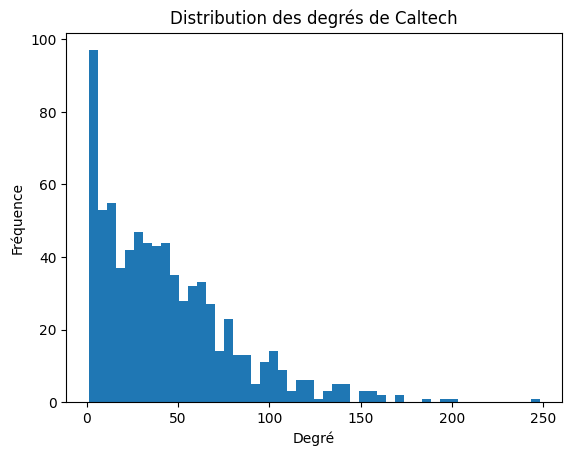

Métriques pour Caltech
Densité: 0.05742892519512591
Clustering global: 0.2912809635141533
Clustering moyen: 0.4091173048334612


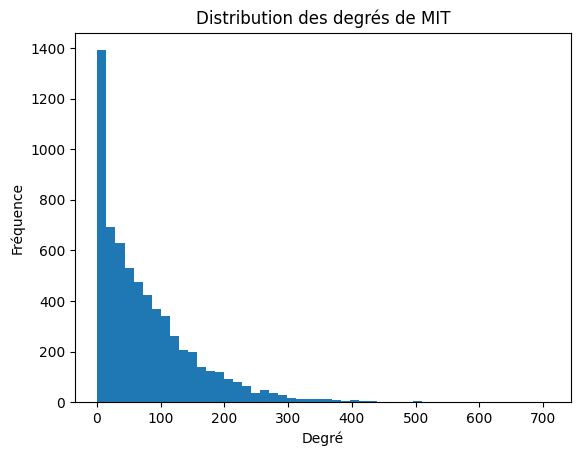

Métriques pour MIT
Densité: 0.012261341741110527
Clustering global: 0.1802884023054581
Clustering moyen: 0.27235999658838644


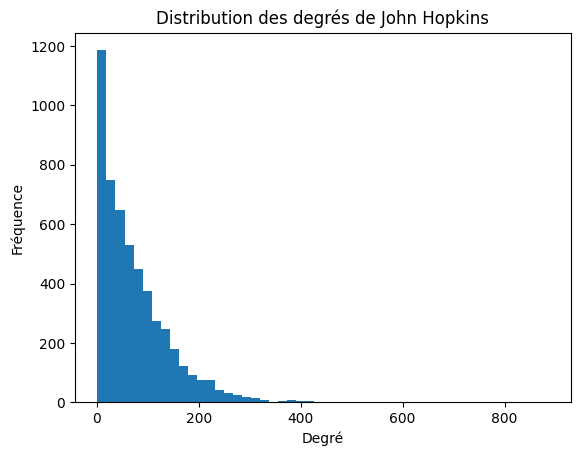

Métriques pour John Hopkins
Densité: 0.0140335136902954
Clustering global: 0.19316115952994883
Clustering moyen: 0.26900836180589566


In [39]:
import networkx as nx
import matplotlib.pylab as plt

# Charge le graphe et renvoie sa plus grande composante connexe
# Prend le chemin de la donnée en argument
def load_LCC(path):
    G = nx.read_gml(path)
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

# Graphe des 3 réseaux
graphes = {"Caltech": load_LCC("../data/Caltech36.gml"),
           "MIT": load_LCC("../data/MIT8.gml"),
           "John Hopkins": load_LCC("../data/Johns Hopkins55.gml")}

for name, G in graphes.items():
    # Distribution des degrés
    degrees = [d for _, d in G.degree()]
    plt.hist(degrees, bins=50)
    plt.title(f"Distribution des degrés de {name}")
    plt.xlabel("Degré")
    plt.ylabel("Fréquence")
    plt.show()

    # Densité et clustering
    density = nx.density(G)
    global_clustering = nx.transitivity(G)
    local_clustering = nx.average_clustering(G)

    print(f"Métriques pour {name}")
    print(f"Densité: {density}")
    print(f"Clustering global: {global_clustering}")
    print(f"Clustering moyen: {local_clustering}")

#### b)

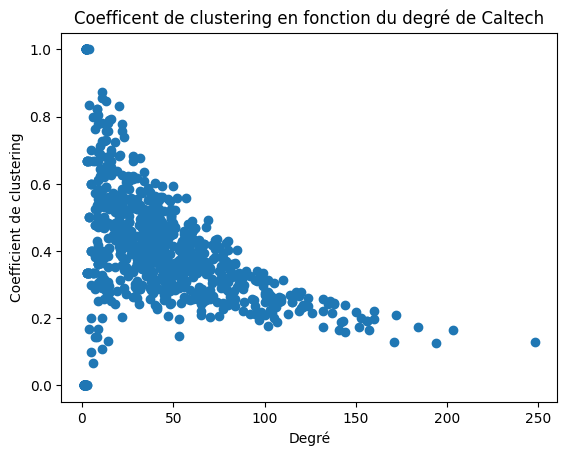

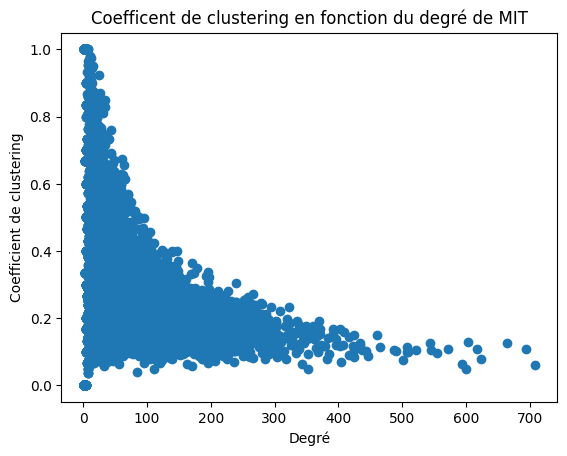

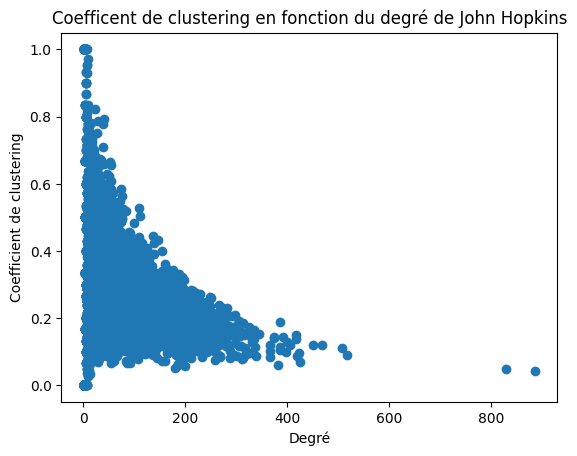

In [40]:
for name, G in graphes.items():
    degrees = dict(G.degree())
    clustering = nx.clustering(G)
    
    x = []
    y = []
    
    for node in G.nodes():
        x.append(degrees[node])
        y.append(clustering[node])

    plt.title(f"Coefficent de clustering en fonction du degré de {name}")
    plt.scatter(x, y)
    plt.xlabel("Degré")
    plt.ylabel("Coefficient de clustering")
    plt.show()

### Question 3

In [41]:
import networkx as nx
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Attributs à analyser
# Il faut calculer le degré des noeuds car ce n'est pas un attribut direct des noeuds du graphe
attributes = ["student_fac", "major_index", "degre", "dorm", "gender"]

# Stockage des résultats
results = {}
for attr in attributes:
    results[attr] = []
sizes = []

# Chargement des graphes (n graphes)
# Charge tous les graphes du dataset si n > nombre de graphes du dataset ou n < 0
# On utilise n pour éviter de charger tous les graphes (car cela prend du temps)
n = -1
data_folder_path = "../data"

gml_files = [f for f in os.listdir(data_folder_path) if f.endswith(".gml")]
gml_files = gml_files[:n]
bar = tqdm(gml_files)
for file in bar:
    # Customisation de la barre de tqdm
    bar.set_description(f"Chargement de {file}")
    
    if file.endswith(".gml"):
        path = os.path.join(data_folder_path, file)

        try:
            # Chargement du graphe
            G = load_LCC(path)

            length = len(G)
            sizes.append(length)

            bar.set_description(f"{file} (n={length})")

            # Calcul de l'assortativité pour chaque attribut
            for attr in attributes:
                if attr != "degre":
                    r = nx.attribute_assortativity_coefficient(G, attr)
                else:
                    r = nx.degree_assortativity_coefficient(G)
                results[attr].append(r)
        except Exception as e:
            # Utilisé pour le debug
            print(f"Erreur avec {file} : {e}")

# Graphiques
for attr in attributes:
    plt.figure()
    plt.scatter(sizes, results[attr], alpha=0.6)
    plt.xscale("log")
    plt.axhline(0, linestyle='--')
    plt.xlabel("Taille du réseau (log)")
    plt.ylabel(f"Assortativité ({attr})")
    plt.title(f"Assortativité vs taille du réseau ({attr})")
    plt.show()

# Histogramme
for attr in attributes:
    plt.figure()
    plt.hist(results[attr], bins=20)
    plt.axvline(0, linestyle='--')
    plt.xlabel("Assortativité")
    plt.ylabel("Fréquence")
    plt.title(f"Distribution de l'assortativité ({attr})")
    plt.show()

BU10.gml (n=19666):  53%|████████████           | 52/99 [24:27<22:06, 28.21s/it]


KeyboardInterrupt: 

### Question 4

#### b)

In [6]:
from abc import ABC, abstractmethod
import networkx as nx
import numpy as np
import progressbar

class LinkPrediction(ABC):
    def __init__(self, graph):
        """
        Constructor

        Parameters
        ----------
            graph: Networkx graph
        """
        self.graph = graph
        self.N = len(graph)

    def neighbors(self, v):
        """
        Return the neighbors list of a node

        Parameters
        ----------
            v: int
                node id

        Return
        ------
            neighbors_list: python list
        """
        neighbors_list = self.graph.neighbors(v)
        return list(neighbors_list)

    @abstractmethod
    def fit(self):
        raise NotImplementedError("Fit must be implemented")

In [7]:
class CommonNeighbors(LinkPrediction):
    def __init__(self, graph):
        super(CommonNeighbors, self).__init__(graph)

    def fit(self):
        scores = []
        nodes = list(self.graph.nodes())

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                u = nodes[i]
                v = nodes[j]

                # On fait de la prédiction de liens donc il ne faut pas que les 2 soient connectés
                if not self.graph.has_edge(u, v):
                    # On utilise des sets pour pouvoir calculer rapidement et facilement les intersection et union
                    # Voisins de u
                    nu = set(self.neighbors(u))
                    # Voisins de v
                    nv = set(self.neighbors(v))
                    # Intersection entre nu et nv
                    inter = nu & nv
                    score = len(inter)
                    scores.append((u, v, score))

        return scores

In [8]:
class Jaccard(LinkPrediction):
    def __init__(self, graph):
        super(Jaccard, self).__init__(graph)

    def fit(self):
        scores = []
        nodes = list(self.graph.nodes())

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                u = nodes[i]
                v = nodes[j]
                
                # On fait de la prédiction de liens donc il ne faut pas que les 2 soient connectés
                if not self.graph.has_edge(u, v):
                    # On utilise des sets pour pouvoir calculer rapidement et facilement les intersection et union
                    # Voisins de u
                    nu = set(self.neighbors(u))
                    # Voisins de v
                    nv = set(self.neighbors(v))
                    # Intersection entre nu et nv
                    inter = nu & nv
                    # Union entre nu et nv
                    union = nu | nv

                    if len(union) == 0:
                        score = 0
                    else:
                        score = len(inter)/len(union)

                    scores.append((u, v, score))

        return scores

In [9]:
from math import log

class AdamicAdar(LinkPrediction):
    def __init__(self, graph):
        super(AdamicAdar, self).__init__(graph)

    def fit(self):
        scores = []
        nodes = list(self.graph.nodes())

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                u = nodes[i]
                v = nodes[j]
                
                # On fait de la prédiction de liens donc il ne faut pas que les 2 soient connectés
                if not self.graph.has_edge(u, v):
                    # On utilise des sets pour pouvoir calculer rapidement et facilement les intersection et union
                    # Voisins de u
                    nu = set(self.neighbors(u))
                    # Voisins de v
                    nv = set(self.neighbors(v))
                    # Intersection entre nu et nv
                    inter = nu & nv

                    score = 0
                    for z in inter:
                        deg = len(self.neighbors(z))
                        if deg > 1:
                            score += 1/log(deg)

                    scores.append((u, v, score))

        return scores

#### c)

In [10]:
import random
from tqdm import tqdm

def remove_edges(G_source, fraction):
    """Supprime une fraction des arêtes de manière random et renvoie ce nouveau graphe."""
    G = G_source.copy()
    edges = list(G.edges())

    # On calcule le nombre d'arêtes à supprimer
    nb_remove = int(len(edges) * fraction)
    e_removed = random.sample(edges, nb_remove)

    # On supprime les arêtes sélectionnées
    G.remove_edges_from(e_removed)

    return G, e_removed

def evaluate_model(scores, e_removed, k_list):
    results = {}
    
    # On tri les arêtes car le graphe est non orienté et si on ne le faisait pas on aurait des erreurs de calcul
    # Car on aurait (u, v) != (v, u)
    removed_set = set(tuple(sorted(e)) for e in e_removed)

    for k in k_list:
        top_k = scores[:k]

        # De même, on tri les arêtes
        predicted = set(tuple(sorted((u, v))) for u, v, _ in top_k)

        # Calcul des vrai positif
        tp = len(predicted & removed_set)

        # Precision : On n'a pas détecté des arêtes qui n'existe pas
        # |TP| + |FP| = k
        # Ce qui fait que top@k = precision@k
        if k > 0:
            precision = tp / k
        else:
            precision = 0

        # Recall : On n'a pas oublié de détecter des arêtes qui existe
        # |TP| + |FN| = len(removed_set)
        if len(removed_set) > 0:
            recall = tp / len(removed_set)
        else:
            recall = 0

        results[k] = (precision, recall)

    return results

def link_prediction(G_source, fractions):
    """Fait les étapes 2 à 5 de la 4c"""
    for fraction in fractions:
        print("---------------------------------------------")
        print(f"Fraction d'arêtes supprimées : {fraction}")
        # 2. Suppression d'une fraction des arêtes
        G_train, e_removed = remove_edges(G_source, fraction)
        
        # 3. Calcul de la prédiction de lien
        common_neighbors = CommonNeighbors(G_train)
        jaccard = Jaccard(G_train)
        adamic_adar = AdamicAdar(G_train)
        
        models = {
            "Common Neighbors": common_neighbors,
            "Jaccard": jaccard,
            "AdamicAdar": adamic_adar
        }
        
        for name, model in models.items():
            print(name)
            scores = model.fit()
    
            # 4. Tri des arêtes par score
            scores.sort(key=lambda x: x[2], reverse=True)
    
            # 5. Evaluation des modèles
            k_list = [50, 100, 200, 400]
            results = evaluate_model(scores, e_removed, k_list)
        
            for k, (precision, recall) in results.items():
                print(f"k={k} -> precision@k={precision:.4f}, recall@k={recall:.4f}")

# 1. Initialision du graphe
# (On n'utilise pas load_LCC car on veut travailler sur tout le graphe)
paths = ["../data/Caltech36.gml", "../data/Reed98.gml", "../data/Simmons81.gml"]
fractions = [0.05, 0.1, 0.15, 0.2]
bar = tqdm(paths)
for path in bar:
    bar.set_description(f"Chargement de {path}")
    G_source = nx.read_gml(path)
    link_prediction(G_source, fractions)

Chargement de ../data/Caltech36.gml:   0%|                | 0/3 [00:00<?, ?it/s]

---------------------------------------------
Fraction d'arêtes supprimées : 0.05
Common Neighbors
k=50 -> precision@k=0.4600, recall@k=0.0276
k=100 -> precision@k=0.4500, recall@k=0.0541
k=200 -> precision@k=0.3550, recall@k=0.0853
k=400 -> precision@k=0.2800, recall@k=0.1346
Jaccard
k=50 -> precision@k=0.3200, recall@k=0.0192
k=100 -> precision@k=0.3300, recall@k=0.0397
k=200 -> precision@k=0.2750, recall@k=0.0661
k=400 -> precision@k=0.2150, recall@k=0.1034
AdamicAdar
k=50 -> precision@k=0.4400, recall@k=0.0264
k=100 -> precision@k=0.4500, recall@k=0.0541
k=200 -> precision@k=0.3550, recall@k=0.0853
k=400 -> precision@k=0.2825, recall@k=0.1358
---------------------------------------------
Fraction d'arêtes supprimées : 0.1
Common Neighbors
k=50 -> precision@k=0.7000, recall@k=0.0210
k=100 -> precision@k=0.6000, recall@k=0.0360
k=200 -> precision@k=0.5050, recall@k=0.0607
k=400 -> precision@k=0.4200, recall@k=0.1009
Jaccard
k=50 -> precision@k=0.4200, recall@k=0.0126
k=100 -> precisi

Chargement de ../data/Reed98.gml:  33%|███▋       | 1/3 [00:25<00:51, 25.88s/it]

k=50 -> precision@k=0.7800, recall@k=0.0117
k=100 -> precision@k=0.7700, recall@k=0.0231
k=200 -> precision@k=0.7150, recall@k=0.0429
k=400 -> precision@k=0.6375, recall@k=0.0766
---------------------------------------------
Fraction d'arêtes supprimées : 0.05
Common Neighbors
k=50 -> precision@k=0.2000, recall@k=0.0106
k=100 -> precision@k=0.1600, recall@k=0.0170
k=200 -> precision@k=0.1400, recall@k=0.0298
k=400 -> precision@k=0.1400, recall@k=0.0596
Jaccard
k=50 -> precision@k=0.2200, recall@k=0.0117
k=100 -> precision@k=0.1900, recall@k=0.0202
k=200 -> precision@k=0.2050, recall@k=0.0436
k=400 -> precision@k=0.2025, recall@k=0.0862
AdamicAdar
k=50 -> precision@k=0.2000, recall@k=0.0106
k=100 -> precision@k=0.2000, recall@k=0.0213
k=200 -> precision@k=0.1650, recall@k=0.0351
k=400 -> precision@k=0.1400, recall@k=0.0596
---------------------------------------------
Fraction d'arêtes supprimées : 0.1
Common Neighbors
k=50 -> precision@k=0.5200, recall@k=0.0138
k=100 -> precision@k=0.4

Chargement de ../data/Simmons81.gml:  67%|█████▎  | 2/3 [01:03<00:32, 32.75s/it]

k=50 -> precision@k=0.5400, recall@k=0.0072
k=100 -> precision@k=0.5800, recall@k=0.0154
k=200 -> precision@k=0.5200, recall@k=0.0276
k=400 -> precision@k=0.4525, recall@k=0.0481
---------------------------------------------
Fraction d'arêtes supprimées : 0.05
Common Neighbors
k=50 -> precision@k=0.5000, recall@k=0.0152
k=100 -> precision@k=0.3700, recall@k=0.0224
k=200 -> precision@k=0.3250, recall@k=0.0394
k=400 -> precision@k=0.2450, recall@k=0.0594
Jaccard
k=50 -> precision@k=0.1800, recall@k=0.0055
k=100 -> precision@k=0.2000, recall@k=0.0121
k=200 -> precision@k=0.1500, recall@k=0.0182
k=400 -> precision@k=0.1325, recall@k=0.0321
AdamicAdar
k=50 -> precision@k=0.5000, recall@k=0.0152
k=100 -> precision@k=0.3800, recall@k=0.0230
k=200 -> precision@k=0.3300, recall@k=0.0400
k=400 -> precision@k=0.2700, recall@k=0.0655
---------------------------------------------
Fraction d'arêtes supprimées : 0.1
Common Neighbors
k=50 -> precision@k=0.7200, recall@k=0.0109
k=100 -> precision@k=0.5

Chargement de ../data/Simmons81.gml: 100%|████████| 3/3 [02:43<00:00, 54.34s/it]

k=50 -> precision@k=0.8200, recall@k=0.0062
k=100 -> precision@k=0.8200, recall@k=0.0124
k=200 -> precision@k=0.7550, recall@k=0.0229
k=400 -> precision@k=0.6775, recall@k=0.0411


#### e)

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

class GNNEncoder(nn.Module):
    # On veut transformer les vecteurs en embedding
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        # On met 2 couches, on va regarder les voisins de x et les voisins des voisins de x
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

class LinkPredictor(nn.Module):
    # A partir des embedding des noeuds, on va prédire les liens
    def __init__(self, hidden_channels):
        super().__init__()
        self.lin = nn.Linear(hidden_channels * 2, 1)

    def forward(self, z, edge_label_index):
        src = z[edge_label_index[0]]
        dst = z[edge_label_index[1]]
        x = torch.cat([src, dst], dim=1)
        return torch.sigmoid(self.lin(x)).view(-1)

class GNNModel(nn.Module):
    # On combine les deux
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.encoder = GNNEncoder(in_channels, hidden_channels)
        self.predictor = LinkPredictor(hidden_channels)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encoder(x, edge_index)
        return self.predictor(z, edge_label_index)

In [ ]:
from torch_geometric.utils import from_networkx, negative_sampling
from torch_geometric.transforms import RandomLinkSplit
import networkx as nx
import torch.optim as optim

def precision_recall_k(model, train_data, test_data, k):
    model.eval()

    with torch.no_grad():
        scores = model(train_data.x, train_data.edge_index, test_data.edge_label_index)

    scores = scores.cpu()
    labels = test_data.edge_label.cpu()

    idx = torch.argsort(scores, descending=True)

    top_k = idx[:k]

    tp = labels[top_k].sum().item()
    fp = k - tp
    fn = labels.sum().item() - tp

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    return precision, recall

def features(G):
    # Renvoie les features des noeuds
    nodes = list(G.nodes(data=True))

    features = []

    for _, attr in nodes:
        # Comme le genre est faiblement assortatif, il nous en apprendra très peu
        # on le néglige donc pour rendre l'entrainement plus rapide
        feat = [
            attr['student_fac'],
            attr['major_index'],
            attr['dorm'],
        ]
        features.append(feat)

    x = torch.tensor(features, dtype=torch.float)

    return x

G = nx.read_gml("../data/Caltech36.gml")

data = from_networkx(G)
data.x = features(G)
# Normalisations des features
data.x = (data.x - data.x.mean(dim=0)) / data.x.std(dim=0)

# On veut séparer nos données : 
# Un partie pour l'entrainement du modèle pour ajuster les poids et une autre partie pour les tests
transform = RandomLinkSplit(
    num_val=0,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=True
)
train_data, val_data, test_data = transform(data)

# Création du modèle
model = GNNModel(
    in_channels=data.x.size(1),
    hidden_channels=32
)

# Initilisation de l'optimiseur pour l'ajustement des poids
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Lancement de l'entrainement
# On met 100 epochs car la loss ne diminue plus beaucoup après
nb_epochs = 100
for epoch in range(1, nb_epochs+1):
    model.train()
    optimizer.zero_grad()

    # Résultat
    out = model(train_data.x, train_data.edge_index, train_data.edge_label_index)

    # Calcul de la loss
    loss = torch.nn.functional.binary_cross_entropy(out, train_data.edge_label)

    loss.backward()
    # Correction des poids
    optimizer.step()

    print(f"Epoch {epoch} : loss = {loss.item():.4f}")

for k in [50, 100, 200, 400]:
    precision, recall = precision_recall_k(model, train_data, test_data, k)
    print(f"k={k} -> precision@k={precision:.4f}, recall@k={recall:.4f}")

### Question 5

#### b)

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import numpy as np
import scipy.sparse as sp
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error

# Chargement du graphe
name = "Cal65"
print(f"Chargement de {name}")
path = f"../data/{name}.gml"
# On garde uniquement la plus grande composante connexe
G = load_LCC(path)

attributes = {
    "major_index": "Major",
    "dorm": "Dorm",
    "year": "Year",
    "gender": "Gender"
}

# On renumérote les noeuds pour torch
G = nx.convert_node_labels_to_integers(G)
n = G.number_of_nodes()
print(f"Nombre de noeuds dans la LCC : {n}")

# Construit la matrice d'adjacence normalisé avec les selfs loop
def build_normalized_adj_matrix(G):
    A = nx.adjacency_matrix(G)
    # Chaque noeud se connecte à lui-même (self-loop)
    A_sl = A + sp.eye(A.shape[0])

    # Matrice des degrés
    D = np.array(A_sl.sum(axis=1)).flatten()
    # Calcul de D^(-1/2)
    D_inv_sqrt = sp.diags(D ** -0.5)

    # Calcul final
    A_hat = D_inv_sqrt @ A_sl @ D_inv_sqrt
    # Comme la matrice est sparse, on ne garde pas en mémoire les 0
    A_hat = A_hat.tocoo()

    # Conversion en tenseur sparse PyTorch
    indices = torch.from_numpy(
        np.vstack([A_hat.row, A_hat.col]).astype(np.int64)
    )
    values = torch.from_numpy(A_hat.data.astype(np.float32))
    shape = torch.Size(A_hat.shape)
    return torch.sparse_coo_tensor(indices, values, shape)

A_hat = build_normalized_adj_matrix(G)

# Construit la matrice de features
def build_feature_matrix(G, nodes, attrs):
    encoders = {}
    r = {a: [] for a in attrs}

    # On récupère les attributs des noeuds
    for n in nodes:
        d = G.nodes[n]
        for a in attrs:
            r[a].append(d.get(a, 0))

    # Encodage des attributs qui sont des catégories
    parts = []
    for a in attrs:
        le = LabelEncoder()
        encoded = le.fit_transform(r[a])
        encoders[a] = le
        n_classes = len(le.classes_)
        if n_classes == 1:
            parts.append(encoded.reshape(-1, 1).astype(np.float32))
        else:
            one_hot = np.zeros((len(encoded), n_classes), dtype=np.float32)
            one_hot[np.arange(len(encoded)), encoded] = 1.0
            parts.append(one_hot)

    # On concatène les matrices (ou vecteur) de chaque attribut
    X = np.concatenate(parts, axis=1)
    # Conversion en tensor pour torch
    return torch.tensor(X, dtype=torch.float32), encoders

nodes = list(G.nodes())
feature_attrs = attributes.keys()
X, encoders = build_feature_matrix(G, nodes, feature_attrs)

# On divise les données pour l'entrainement et les tests
idx = list(range(n))
random.shuffle(idx)
split = int(0.5 * n)
train_idx = torch.tensor(idx[:split], dtype=torch.long)
test_idx  = torch.tensor(idx[split:], dtype=torch.long)

Chargement de Cal65
Nombre de noeuds dans la LCC : 11243


In [35]:

class GCNLayer(nn.Module):
    # Une couche du GCN
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        # Initialisation de Glorot
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, H, A_hat):
        AH = torch.sparse.mm(A_hat, H)
        return self.W(AH)


class GCN(nn.Module):
    # GCN à 2 couches
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.layer1 = GCNLayer(in_features, hidden_dim)
        self.layer2 = GCNLayer(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, X, A_hat):
        # Couche 1 : ReLU + Dropout
        H = F.relu(self.layer1(X, A_hat))
        H = F.dropout(H, p=self.dropout, training=self.training)
        # Couche 2 : LogSoftmax
        Z = self.layer2(H, A_hat)
        return F.log_softmax(Z, dim=1)

In [36]:
def prepare_data(G, nodes, label_attr):
    # Construit les features, les labels et donne le nombre de classes
    X, _ = build_feature_matrix(G, nodes, feature_attrs)

    raw_labels = [G.nodes[n].get(label_attr, -1) for n in nodes]
    le = LabelEncoder()
    y = torch.tensor(le.fit_transform(raw_labels), dtype=torch.long)

    return X, y, len(le.classes_)

def run_experiment(G, nodes, A_hat, label_attr, fraction):
    # Prépare les données
    X, y, num_classes = prepare_data(G, nodes, label_attr)
    N = len(nodes)

    # On cache de manière random une fraction des attributs
    mask = np.random.rand(N) < fraction

    # Séparation pour l'entrainement et les tests
    train_idx = torch.tensor(np.where(~mask)[0], dtype=torch.long)
    test_idx  = torch.tensor(np.where(mask)[0], dtype=torch.long)

    # Initialisation du modèle
    model = GCN(
        in_features=X.shape[1],
        hidden_dim=64,
        num_classes=num_classes,
        dropout=0.5
    )

    # Initialisation de l'optimiseur pour l'ajustement des points et du criterion pour la loss
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = nn.NLLLoss()

    # Lancement de l'entrainement
    best_loss = float('inf')
    # On veut s'arrêter après wait epochs sans amélioration
    wait = 10
    counter = 0
    for epoch in range(200):
        model.train()
        optimizer.zero_grad()

        out = model(X, A_hat)
        loss = criterion(out[train_idx], y[train_idx])
        
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= wait:
                break

    # On ne veut garder que le meilleur état des poids (et pas le dernier), donc celui qui minimise la loss
    model.load_state_dict(best_state)

    # Lancement des tests
    model.eval()
    with torch.no_grad():
        out = model(X, A_hat)
        # On prend uniquement les noeuds de test
        pred = out[test_idx].argmax(dim=1)

    accuracy = accuracy_score(y[test_idx].cpu(), pred.cpu())
    mae = mean_absolute_error(y[test_idx].cpu(), pred.cpu())
    
    return accuracy, mae

fractions = [0.1, 0.2, 0.3, 0.4]

# Lancement de l'entrainement du modèle puis des tests
for attr, name in attributes.items():
    print(f"{name}:")

    for fraction in fractions:
        acc, mae = run_experiment(G, nodes, A_hat, attr, fraction)
        print(f"Fraction = {fraction:.1f} - Accuracy = {acc:.3f} - MAE = {mae:.3f}")

    print()

Major:
Fraction = 0.1 - Accuracy = 0.461 - MAE = 11.838
Fraction = 0.2 - Accuracy = 0.460 - MAE = 12.004
Fraction = 0.3 - Accuracy = 0.460 - MAE = 11.914
Fraction = 0.4 - Accuracy = 0.462 - MAE = 11.570

Dorm:
Fraction = 0.1 - Accuracy = 0.737 - MAE = 8.410
Fraction = 0.2 - Accuracy = 0.714 - MAE = 8.873
Fraction = 0.3 - Accuracy = 0.727 - MAE = 8.529
Fraction = 0.4 - Accuracy = 0.716 - MAE = 8.844

Year:
Fraction = 0.1 - Accuracy = 0.665 - MAE = 3.680
Fraction = 0.2 - Accuracy = 0.673 - MAE = 3.407
Fraction = 0.3 - Accuracy = 0.665 - MAE = 3.409
Fraction = 0.4 - Accuracy = 0.659 - MAE = 3.633

Gender:
Fraction = 0.1 - Accuracy = 0.837 - MAE = 0.186
Fraction = 0.2 - Accuracy = 0.849 - MAE = 0.175
Fraction = 0.3 - Accuracy = 0.837 - MAE = 0.186
Fraction = 0.4 - Accuracy = 0.837 - MAE = 0.184



### Question 6

#### b)

In [47]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from collections import Counter
from tqdm import tqdm

def analyze_student_fac(path): 
    # Cette fois-ci on veut regarder tout le graphe car on fait une hypothèse globale
    G = nx.read_gml(path)

    # On détecte et compte les communautés
    communities = list(greedy_modularity_communities(G))

    print("Nombre de communautés :", len(communities))

    # On limite à 5 l'affichage pour éviter de polluer l'affichage
    for i, comm in enumerate(communities[:5]):
        dorms = [G.nodes[n]["student_fac"] for n in comm if G.nodes[n]["student_fac"] != 0]

        if len(dorms) == 0:
            continue

        count = Counter(dorms)
        most_common, freq = count.most_common(1)[0]

        prop = freq / len(dorms)

        print(f"Communauté {i}: taille={len(comm)}")
        print(f"  Status social dominant = {most_common}")
        print(f"  Proportion du status social dominant = {prop:.2f}")

data_path = "../data/"
files = ["Caltech36.gml", "Simmons81.gml", "Reed98.gml"]
bar = tqdm(files)

for file in bar:
    # Customisation de la barre tqdm
    bar.set_description(f"Chargement de {file}")
    analyze_dorms(f"{data_path}{file}")

Chargement de Simmons81.gml:  33%|█████▎          | 1/3 [00:03<00:06,  3.27s/it]

Nombre de communautés : 11
Communauté 0: taille=314
  Status social dominant = 1
  Proportion du status social dominant = 0.76
Communauté 1: taille=285
  Status social dominant = 1
  Proportion du status social dominant = 0.75
Communauté 2: taille=116
  Status social dominant = 1
  Proportion du status social dominant = 0.63
Communauté 3: taille=28
  Status social dominant = 1
  Proportion du status social dominant = 0.64
Communauté 4: taille=10
  Status social dominant = 5
  Proportion du status social dominant = 0.80


Chargement de Reed98.gml:  67%|████████████▋      | 2/3 [00:14<00:07,  7.92s/it]

Nombre de communautés : 11
Communauté 0: taille=747
  Status social dominant = 1
  Proportion du status social dominant = 0.76
Communauté 1: taille=428
  Status social dominant = 1
  Proportion du status social dominant = 0.96
Communauté 2: taille=311
  Status social dominant = 1
  Proportion du status social dominant = 1.00
Communauté 3: taille=15
  Status social dominant = 1
  Proportion du status social dominant = 0.93
Communauté 4: taille=5
  Status social dominant = 5
  Proportion du status social dominant = 0.80


Chargement de Reed98.gml: 100%|███████████████████| 3/3 [00:19<00:00,  6.43s/it]

Nombre de communautés : 4
Communauté 0: taille=456
  Status social dominant = 1
  Proportion du status social dominant = 0.98
Communauté 1: taille=424
  Status social dominant = 1
  Proportion du status social dominant = 0.67
Communauté 2: taille=77
  Status social dominant = 1
  Proportion du status social dominant = 0.96
Communauté 3: taille=5
  Status social dominant = 2
  Proportion du status social dominant = 0.60


In [52]:
from networkx.algorithms.community import greedy_modularity_communities
from collections import Counter
import numpy as np
import networkx as nx

def analyze_dorm(G):
    # On détecte et compte les communautés
    communities = list(greedy_modularity_communities(G))

    attr = "dorm"

    sizes = []
    props = []

    for commu in communities:
        values = [G.nodes[n].get(attr, None) for n in commu if G.nodes[n].get(attr, None) is not None]

        if len(values) == 0:
            continue

        count = Counter(values)
        dominant, freq = count.most_common(1)[0]

        prop = freq / len(values)

        sizes.append(len(commu))
        props.append(prop)

    return sizes, props


data_path = "../data/"
files = ["Caltech36.gml", "Simmons81.gml", "Reed98.gml"]
bar = tqdm(files)

for file in bar:
    # Customisation de la barre tqdm
    bar.set_description(f"Chargement de {file}")
    path = f"{data_path}{file}"
    G = nx.read_gml(path)
    
    sizes, props = analyze_dorm(G)
    print("Taille moyenne des communautés :", np.mean(sizes))
    print("Proportion moyenne du dortoir dominant :", np.mean(props))
    print("Corrélation taille/proportion :", np.corrcoef(sizes, props)[0,1])

Chargement de Simmons81.gml:  33%|█████▎          | 1/3 [00:03<00:06,  3.44s/it]

Taille moyenne des communautés : 69.9090909090909
Proportion moyenne du dortoir dominant : 0.6970586895928197
Corrélation taille/proportion : -0.7343715404374184


Chargement de Reed98.gml:  67%|████████████▋      | 2/3 [00:14<00:08,  8.20s/it]

Taille moyenne des communautés : 138.0
Proportion moyenne du dortoir dominant : 0.8486129666109072
Corrélation taille/proportion : -0.8064773963598191


Chargement de Reed98.gml: 100%|███████████████████| 3/3 [00:20<00:00,  6.70s/it]

Taille moyenne des communautés : 240.5
Proportion moyenne du dortoir dominant : 0.5801537505857267
Corrélation taille/proportion : -0.40883312638423264
